# Subgraphs with Shared State

A LangGraph parent graph that calls a subgraph sharing the *same* state schema as the parent. Because both graphs use `ParentState`, the subgraph can be added directly as a node — no state-mapping adapter needed (contrast with the separate-state version).

## 1. Install required packages

In [1]:
%pip install -qU langgraph langchain-openai python-dotenv

Note: you may need to restart the kernel to use updated packages.


## 2. Setup & imports

In [2]:
import os

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError(
        "OPENAI_API_KEY not found. Add it to a .env file in this notebook's directory."
    )

## 3. Define the shared state & LLMs

Both the parent graph and the subgraph operate on this single `ParentState` schema.

In [3]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str


parent_llm = ChatOpenAI(model="gpt-4o-mini")
subgraph_llm = ChatOpenAI(model="gpt-4o")

## 4. Build the subgraph (translation)

The subgraph reads/writes fields directly on `ParentState` — the same schema the parent uses — so no adapter function is needed at the call site.

In [4]:
def translate_text(state: ParentState):
    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {"answer_hin": translated_text}


subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node("translate_text", translate_text)

subgraph_builder.add_edge(START, "translate_text")
subgraph_builder.add_edge("translate_text", END)

subgraph = subgraph_builder.compile()

## 5. Define the parent graph node

In [5]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(
        f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}"
    ).content
    return {"answer_eng": answer}

## 6. Build, compile & visualize the parent graph

The compiled `subgraph` is added directly as a node — this only works because it shares `ParentState` with the parent graph.

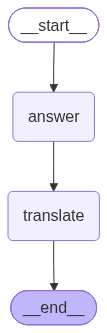

In [6]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, "answer")
parent_builder.add_edge("answer", "translate")
parent_builder.add_edge("translate", END)

graph = parent_builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 7. Run the graph

In [7]:
result = graph.invoke({"question": "What is quantum physics"})

print("--- English answer ---")
print(result["answer_eng"])
print("\n--- Hindi translation ---")
print(result["answer_hin"])

--- English answer ---
Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. It differs from classical physics in several key ways, emphasizing probabilistic outcomes rather than deterministic ones. 

Key concepts in quantum physics include:

1. **Wave-Particle Duality**: Particles, such as electrons and photons, exhibit both wave-like and particle-like properties.
2. **Quantum Superposition**: Particles can exist in multiple states or locations simultaneously until measured or observed.
3. **Entanglement**: Particles can become interconnected such that the state of one particle instantaneously influences the state of another, regardless of distance.
4. **Uncertainty Principle**: Proposed by Werner Heisenberg, this principle states that it is impossible to simultaneously know the exact position and momentum of a particle.

Quantum physics has le